In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helpersGeneration import *

## 1. Simulation parameters

In [2]:
nparticles = 8          # number of particles
nframes = 20            # number of output video frames
nPosPerFrame = 5        # substeps per frame
D = 4                   # diffusion coefficient
dt = 1.0                # time step
startAtZero = True      # all trajectories start at (0,0)

## 2. Generate brownian trajectories

In [3]:
trajectories = brownian_motion(
    nparticles=nparticles,
    nframes=nframes,
    nposframe=nPosPerFrame,
    D=D,
    dt=dt,
    startAtZero=startAtZero
)

print("Trajectories shape:", trajectories.shape)  # (N, T, 2)

Trajectories shape: (8, 100, 2)


## 3. Define image generation parameters

In [4]:
image_props = {
    "particle_intensity": [500, 20],     # [mean, std]
    "NA": 1.46,
    "wavelength": 500e-9,
    "psf_division_factor": 1,
    "resolution": 100e-9,                # effective pixel size
    "output_size": 32,                   # image size in pixels
    "upsampling_factor": 5,
    "background_intensity": [100, 10],   # [mean, std]
    "poisson_noise": 100,                # -1 disables poisson noise
    "trajectory_unit": 100               # use -1 if trajectory already in pixels
}

## 4. Convert trajectories to videos

In [5]:
videos = trajectories_to_video(
    trajectories,
    nPosPerFrame=nPosPerFrame,
    center=True,
    image_props=image_props,
    use_multiprocessing=False
)

print("Videos shape:", videos.shape)  # (N, nframes, H, W)

Videos shape: (8, 20, 32, 32)


## 5. Normalize videos

In [6]:
bg_mean, bg_sigma = image_props["background_intensity"]
part_mean, _ = image_props["particle_intensity"]

videos_norm, stats = normalize_images(
    videos,
    background_mean=bg_mean,
    background_sigma=bg_sigma,
    theoretical_max=part_mean + bg_mean,
    clip_image=True
)

print("Normalization stats:", stats)


Normalization stats: (100, 10, 600)


## 6. Show one particle trajectory

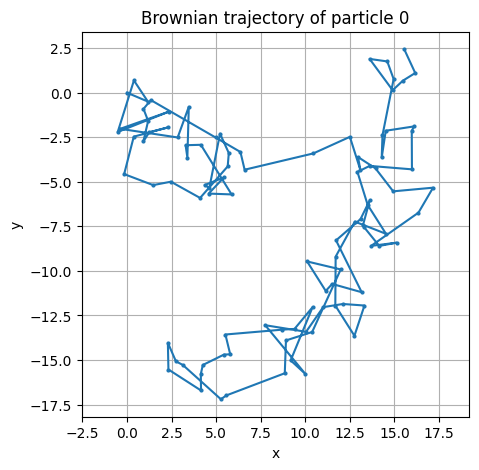

In [7]:
particle_id = 0

traj = trajectories[particle_id]
plt.figure(figsize=(5, 5))
plt.plot(traj[:, 0], traj[:, 1], '-o', markersize=2)
plt.title(f"Brownian trajectory of particle {particle_id}")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.show()

## 7. Show first frame of one video

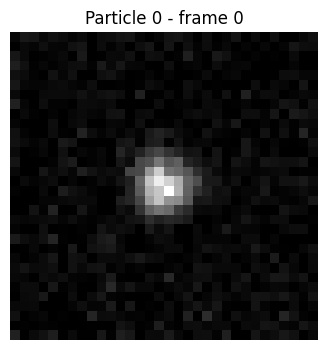

In [8]:
frame_id = 0

plt.figure(figsize=(4, 4))
plt.imshow(videos_norm[particle_id, frame_id], cmap="gray")
plt.title(f"Particle {particle_id} - frame {frame_id}")
plt.axis("off")
plt.show()

## 8. Show a few frames

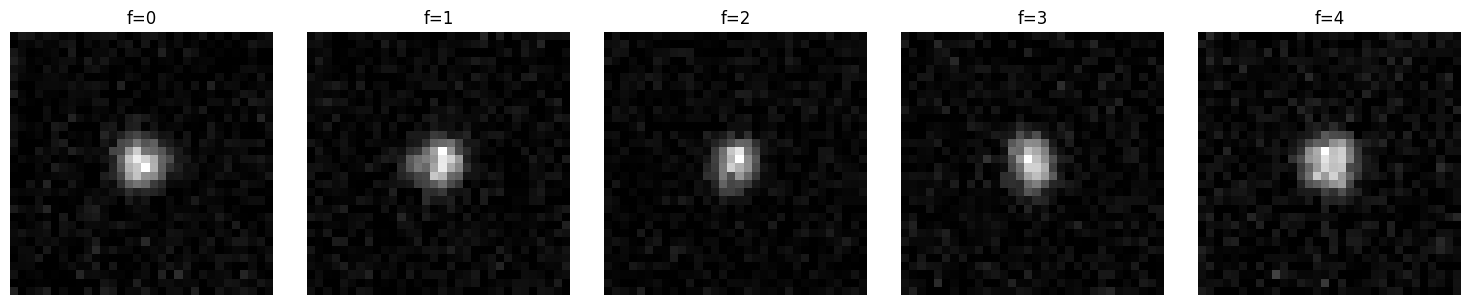

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(videos_norm[particle_id, i], cmap="gray")
    axes[i].set_title(f"f={i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# Version with multiple Ds

In [10]:
D_values = [0.05, 1.5, 4]
n_per_group = 4

traj_groups = []
labels = []

for D in D_values:
    traj = brownian_motion(
        nparticles=n_per_group,
        nframes=20,
        nposframe=5,
        D=D,
        dt=1.0,
        startAtZero=True
    )
    traj_groups.append(traj)
    labels.extend([D] * n_per_group)

trajectories = np.concatenate(traj_groups, axis=0)
labels = np.array(labels)

videos = trajectories_to_video(
    trajectories,
    nPosPerFrame=5,
    center=True,
    image_props=image_props,
    use_multiprocessing=False
)

print("Trajectories shape:", trajectories.shape)
print("Videos shape:", videos.shape)
print("Labels:", labels)

Trajectories shape: (12, 100, 2)
Videos shape: (12, 20, 32, 32)
Labels: [0.05 0.05 0.05 0.05 1.5  1.5  1.5  1.5  4.   4.   4.   4.  ]


# Animation

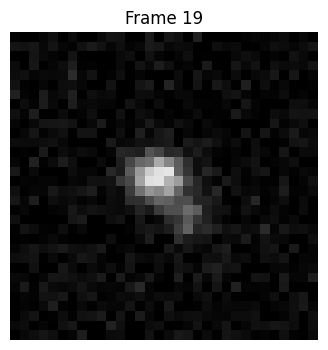

In [18]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

particle_id = 7
video = videos_norm[particle_id]

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(video[0], cmap='gray', animated=True)
ax.axis("off")

def update(frame):
    im.set_array(video[frame])
    ax.set_title(f"Frame {frame}")
    return [im]

ani = FuncAnimation(fig, update, frames=video.shape[0], interval=300, blit=True)
HTML(ani.to_jshtml())